In [3]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data=r"C:\Users\PC-LAB1\Desktop\License-Plate-Data\data.yaml",
    epochs=20,
    imgsz=640
)

Ultralytics 8.4.165  Python-3.12.0 torch-2.14.0+cpu CPU (12th Gen Intel Core i7-12700)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\PC-LAB1\Desktop\License-Plate-Data\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=


image 1/1 C:\Users\PC-LAB1\Desktop\License-Plate-Data\test\images\Cars109.png: 448x640 1 license_plate, 88.8ms
Speed: 5.9ms preprocess, 88.8ms inference, 3.5ms postprocess per image at shape (1, 3, 448, 640)


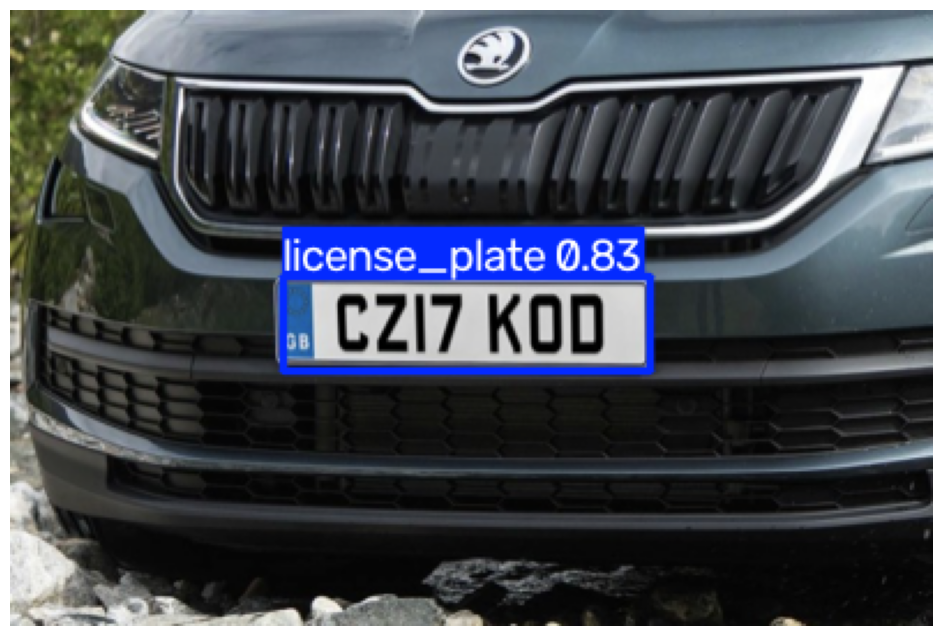

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO(
    r"C:\Users\PC-LAB1\Desktop\shok\runs\detect\train-2\weights\best.pt"
)

image_path = r"C:\Users\PC-LAB1\Desktop\License-Plate-Data\test\images\Cars109.png"

results = model(image_path)

annotated = results[0].plot()

annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

In [5]:
for result in results:
    for box in result.boxes:
        print("Class:", int(box.cls))
        print("Confidence:", float(box.conf))
        print("Bounding box:", box.xyxy.tolist())

Class: 0
Confidence: 0.8268334269523621
Bounding box: [[118.62853240966797, 115.89311218261719, 277.05938720703125, 156.5496368408203]]


In [1]:
import easyocr

reader = easyocr.Reader(["en"])
print("EasyOCR is working")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR is working


c:\Users\PC-LAB1\Desktop\shok\.venv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



0: 448x640 1 license_plate, 105.4ms
Speed: 8.7ms preprocess, 105.4ms inference, 8.1ms postprocess per image at shape (1, 3, 448, 640)
YOLO Confidence: 0.8268334269523621
Detected Text: CZI7 Kod
OCR Confidence: 0.36255742626814963


c:\Users\PC-LAB1\Desktop\shok\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


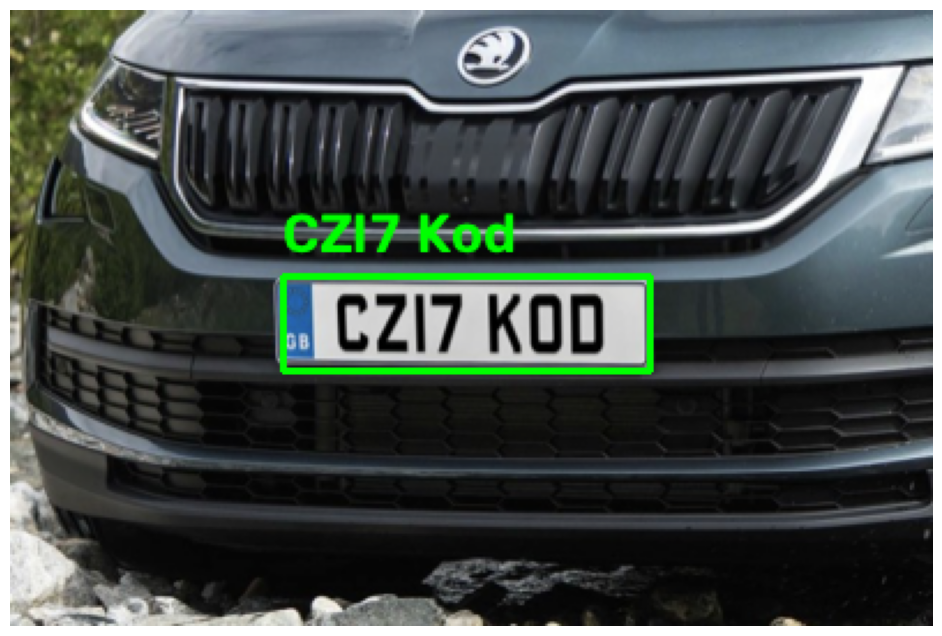

In [2]:
from ultralytics import YOLO
import easyocr
import cv2
import matplotlib.pyplot as plt

# Load trained YOLO model
model = YOLO(
    r"C:\Users\PC-LAB1\Desktop\shok\runs\detect\train-2\weights\best.pt"
)

# Load EasyOCR
reader = easyocr.Reader(["en"])

# Load test image
image_path = r"C:\Users\PC-LAB1\Desktop\License-Plate-Data\test\images\Cars109.png"
image = cv2.imread(image_path)

# YOLO detection
results = model(image)

# Process detections
for result in results:

    for box in result.boxes:

        # Get bounding box
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # YOLO confidence
        yolo_confidence = float(box.conf[0])

        # Crop license plate
        plate = image[y1:y2, x1:x2]

        # Run EasyOCR
        ocr_results = reader.readtext(plate)

        print("YOLO Confidence:", yolo_confidence)

        for detection in ocr_results:
            bbox, text, ocr_confidence = detection

            print("Detected Text:", text)
            print("OCR Confidence:", ocr_confidence)

        # Draw bounding box
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Put OCR text on image
        if ocr_results:
            text = ocr_results[0][1]

            cv2.putText(
                image,
                text,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )

# Convert BGR to RGB for matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Selected image: Cars416.png

0: 480x640 1 license_plate, 42.6ms
Speed: 1.9ms preprocess, 42.6ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
YOLO Confidence: 0.7192521095275879
Detected Text: 172ATMJ
OCR Confidence: 0.23545844174121006


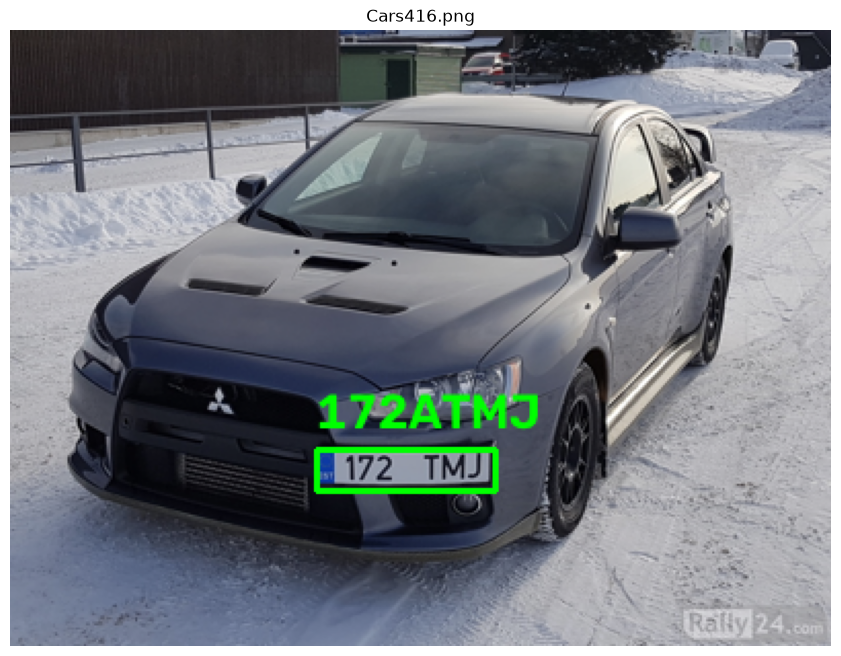

In [25]:
from ultralytics import YOLO
import easyocr
import cv2
import matplotlib.pyplot as plt
import random
import os

# Load trained YOLO model
model = YOLO(
    r"C:\Users\PC-LAB1\Desktop\shok\runs\detect\train-2\weights\best.pt"
)

# Load EasyOCR
reader = easyocr.Reader(["en"])

# Test image folder
image_folder = r"C:\Users\PC-LAB1\Desktop\License-Plate-Data\test\images"

# Get all PNG images
images = [
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.lower().endswith(".png")
]

# Select random image
image_path = random.choice(images)

print("Selected image:", os.path.basename(image_path))

# Load image
image = cv2.imread(image_path)

# YOLO detection
results = model(image)

for result in results:

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        yolo_confidence = float(box.conf[0])

        # Crop license plate
        plate = image[y1:y2, x1:x2]

        # OCR
        ocr_results = reader.readtext(plate)

        print("YOLO Confidence:", yolo_confidence)

        for detection in ocr_results:
            bbox, text, ocr_confidence = detection

            print("Detected Text:", text)
            print("OCR Confidence:", ocr_confidence)

        # Draw YOLO box
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Display OCR text
        if ocr_results:
            text = ocr_results[0][1]

            cv2.putText(
                image,
                text,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )

# Display image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.title(os.path.basename(image_path))
plt.axis("off")
plt.show()